# Impatto dell'intervallo di sanificazione

Valuta la sensibilità della politica dinamica `c_wall` all'intervallo di sanificazione periodica dei nodi (`SANITIZE_INTERVAL_SECONDS`). Configurazione del cluster, workload e grado di conflitto sono fissi in tutti gli scenari: l'unica variabile indipendente è l'intervallo.

**Ipotesi.** Curva a U per la latenza di scheduling. A intervalli brevi i nodi escono spesso da $\mathcal{N}$ e restano indisponibili in attesa del completamento dei task attivi (la sanificazione attende il drain prima di ripulire); a intervalli lunghi le tracce contestuali non vengono ripulite abbastanza in fretta e i task in conflitto restano bloccati. Esiste quindi un intervallo intermedio che minimizza la latenza.

**Nota trasversale su tutte le figure.** La banda attorno alle curve è media ± 1 deviazione standard *tra le repliche*: misura la ripetibilità dell'esperimento, non la dispersione dei singoli task. Agli intervalli grandi (30–45s) la banda si allarga perché in una run di ~120s entrano pochi cicli di sanificazione, e la metrica dipende molto da *quando* cadono quei pochi tick rispetto ai task in esecuzione: la stima è dominata dalla varianza. Questo effetto è coerente in tutte le metriche legate alla sanificazione (latenza, attesa, indisponibilità, makespan).

## Configurazione

In [45]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "analysis")
import analysis.utils as utils

RESULTS_ROOT = Path("results")
SCENARIOS_ROOT = Path("scenarios")
FIG_DIR = Path("analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path("analysis/tables")
TAB_DIR.mkdir(parents=True, exist_ok=True)

INTERVALS = [1, 2, 3, 5, 10, 20, 30, 45]
SCENARIOS = [f"sanitize-{i}" for i in INTERVALS]
POINT_KEY = "sanitize_interval_seconds"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.bbox": "tight",
    }
)

In [ ]:
def band_plot(ax, stats, color, label=None, scale=1.0, marker="o"):
    x = stats.index.to_numpy()
    m = stats["mean"].to_numpy() * scale
    s = stats["std"].fillna(0).to_numpy() * scale
    ax.plot(x, m, marker=marker, color=color, label=label)
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18, linewidth=0)


def set_log_x(ax):
    ax.set_xscale("log")
    ax.set_xticks(INTERVALS)
    ax.set_xticklabels(INTERVALS)
    ax.set_xlabel("Intervallo di sanificazione (s)")


## Caricamento dei dati

In [47]:
tasks, nodes, runs = utils.load_scenarios(RESULTS_ROOT, SCENARIOS, POINT_KEY)
scenario_to_dir = {s: SCENARIOS_ROOT / s for s in SCENARIOS}

print(
    f"task totali: {len(tasks)}  |  run: {runs['replica'].count()}  "
    f"|  intervalli: {sorted(tasks['point'].unique())}"
)
runs.groupby("point")["replica"].nunique().rename("repliche")

task totali: 4000  |  run: 40  |  intervalli: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(45)]


point
1     5
2     5
3     5
5     5
10    5
20    5
30    5
45    5
Name: repliche, dtype: int64

## 1. Parametri dell'esperimento

Riepilogo dei parametri fissi (identici in tutti gli scenari, per isolare l'effetto del solo intervallo) e della griglia della variabile indipendente. Esportato in LaTeX per la tesi. Nota: la durata dei task (10s) fissa la posizione attesa del braccio sinistro della U, perché sotto quella soglia l'intervallo diventa più corto del tempo di drain dei nodi.

In [48]:
r0 = runs.iloc[0]
params = pd.DataFrame(
    {
        "Parametro": [
            "Contesti $K$",
            "Densità di conflitto $\\rho$",
            "Task per run $N$",
            "Rate di sottomissione",
            "Durata task",
            "Nodi worker",
            "Repliche",
            "Intervalli valutati",
        ],
        "Valore": [
            int(tasks["context"].str.extract(r"(\d+)").astype(int).max().iloc[0]),
            r0["conflict_density"],
            int(r0["tasks"]),
            f"1 ogni {r0['rate_seconds']:g}s",
            f"{r0['task_duration_seconds']:g}s",
            nodes["node"].nunique(),
            int(runs.groupby("point")["replica"].nunique().max()),
            ", ".join(f"{i}s" for i in INTERVALS),
        ],
    }
).set_index("Parametro")
display(params)
params.to_latex(TAB_DIR / "sanitize_parametri.tex", escape=False)

,Valore
Parametro,
Contesti $K$,10
Densità di conflitto $\rho$,0.5
Task per run $N$,100
Rate di sottomissione,1 ogni 1s
Durata task,10s
Nodi worker,5
Repliche,5
Intervalli valutati,"1s, 2s, 3s, 5s, 10s, 20s, 30s, 45s"


## 2. Curva principale: latenza di scheduling

**Cosa si valuta.** La latenza di scheduling per task (dalla sottomissione al binding del pod) in funzione dell'intervallo, media e mediana tra repliche.

**Cosa dice il grafico.** La U attesa: minimo intorno a 5–10s, risalita a sinistra (nodi troppo spesso indisponibili) e risalita marcata a destra (tracce ripulite troppo di rado). Il minimo è l'intervallo operativo consigliato.

**Media vs mediana.** Le due curve divergono ampiamente: è la firma della bimodalità della distribuzione. In ogni run coesistono task schedulati subito (latenza ~centesimi di secondo) e task bloccati in attesa di sanificazione (decine di secondi). La mediana segue la popolazione veloce e resta bassa; la media è tirata su dalla coda dei bloccati. La mediana può quindi cadere ben sotto la banda della media: non è un'incongruenza, la banda descrive la variabilità della *media* tra repliche, non l'intervallo in cui cadono i task. La distanza tra le due curve cresce con l'intervallo perché la coda dei bloccati si fa più pesante.

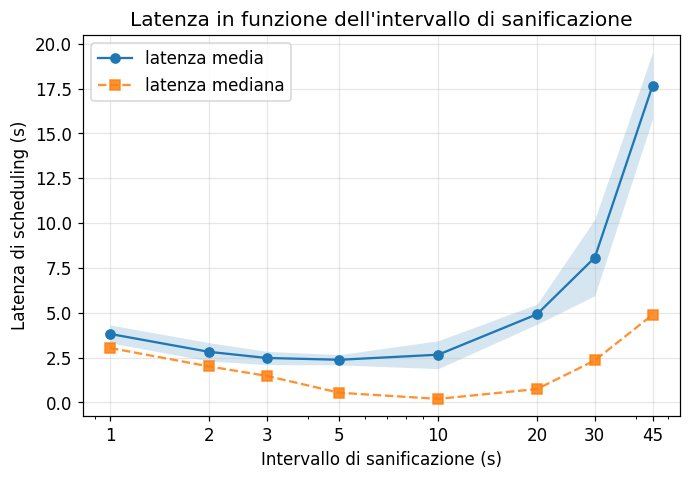

Minimo della latenza media all'intervallo = 5s (2.380s)


In [49]:
lat = utils.per_point_stat(tasks, "latency_s", "mean")
med = utils.per_point_stat(tasks, "latency_s", "median")

fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, lat, "#1f77b4", "latenza media")
ax.plot(med.index, med["mean"], marker="s", ls="--", color="#ff7f0e", alpha=0.85, label="latenza mediana")
set_log_x(ax)
ax.set_ylabel("Latenza di scheduling (s)")
ax.set_title("Latenza in funzione dell'intervallo di sanificazione")
ax.legend()
fig.savefig(FIG_DIR / "sanitize_latenza.pdf")
plt.show()

opt = lat["mean"].idxmin()
print(f"Minimo della latenza media all'intervallo = {opt}s ({lat['mean'].min():.3f}s)")


## 3. Perché la U ha quella forma

Due letture spiegano il meccanismo dietro la curva.

**Ripartizione per causa di blocco.** Ogni task bloccato è classificato per causa: `taint` (il nodo era fuori da $\mathcal{N}$, in sanificazione), `wall` (tracce contestuali in conflitto), `mixed` (entrambe durante l'attesa), `none` (mai bloccato). Attesa: a intervalli brevi domina la componente `taint` (i nodi passano molto tempo in sanificazione), che si assottiglia verso il minimo della U; a intervalli lunghi cresce la componente legata alle tracce (`mixed`). Il minimo di blocco per taint coincide con il minimo della latenza: è la conferma diretta dell'ipotesi. Le barre sommano a 1 per costruzione (media delle frazioni per replica).

**Attesa dei task bloccati.** Tempo medio che un task bloccato attende prima di essere schedulato. Cresce con l'intervallo perché lo sblocco avviene solo al successivo ciclo di sanificazione del nodo: intervallo più lungo, attesa più lunga. È la quantità $E[t_{wait}]$ che, insieme alla probabilità di blocco, determina la latenza media. La banda si allarga a destra per lo stesso effetto "pochi tick per run".

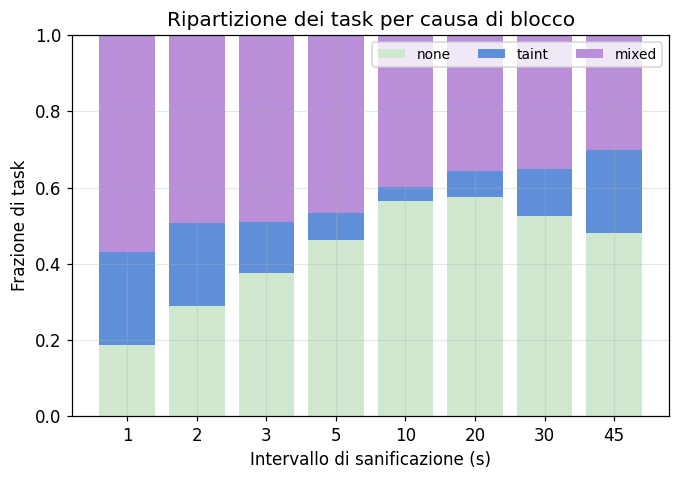

In [50]:
frac = utils.block_fraction_by_cause(tasks)
order = [c for c in ["none", "wall", "taint", "mixed", "other"] if c in frac.columns]
frac = frac[order]
colori = {"none": "#cfe8cf", "wall": "#d95f5f", "taint": "#5f8fd9", "mixed": "#b98fd9", "other": "#999999"}
x = np.arange(len(frac))
bottom = np.zeros(len(frac))
fig, ax = plt.subplots(figsize=(7, 4.5))
for c in order:
    ax.bar(x, frac[c].values, bottom=bottom, label=c, color=colori.get(c))
    bottom += frac[c].values
ax.set_xticks(x)
ax.set_xticklabels(frac.index)
ax.set_ylim(0, 1)
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Frazione di task")
ax.set_title("Ripartizione dei task per causa di blocco")
ax.legend(ncol=len(order), fontsize=9, loc="upper right")
fig.savefig(FIG_DIR / "sanitize_cause_blocco.pdf")
plt.show()


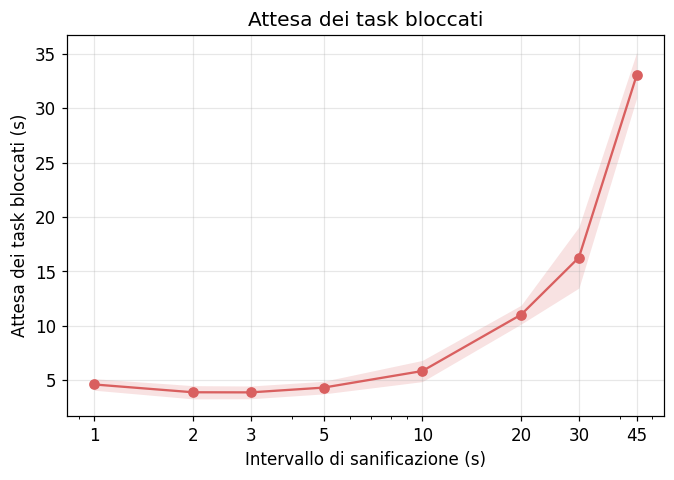

In [51]:
wait = utils.per_point_stat(tasks[tasks["blocked"]], "wait_s", "mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, wait, "#d95f5f")
set_log_x(ax)
ax.set_ylabel("Attesa dei task bloccati (s)")
ax.set_title("Attesa dei task bloccati")
fig.savefig(FIG_DIR / "sanitize_attesa.pdf")
plt.show()


## 4. Disponibilità dei nodi

**Cosa si valuta.** Frazione di tempo in cui i nodi worker sono fuori da $\mathcal{N}$ (taint di sanificazione attivo), integrata sull'intera durata della run e mediata su nodi e repliche. È la controparte del fenomeno vista dal lato cluster, non dal lato task.

**Cosa dice il grafico.** Andamento decrescente: più corto è l'intervallo, più spesso i nodi entrano in sanificazione e vi restano finché i task attivi non completano, quindi maggiore l'indisponibilità. Spiega il braccio sinistro della U dal punto di vista dell'infrastruttura: a intervalli brevi i task non trovano nodi disponibili non per le tracce, ma perché i nodi sono continuamente in pulizia.

**Non-monotonia a 30–45s.** Il valore a 30s risulta più alto che a 45s, apparente inversione dell'andamento. Non è un fatto da giustificare come reale: è dominato dalla varianza. Con run di ~120s, a 45s entrano solo ~2 cicli di sanificazione, e la frazione di indisponibilità dipende fortemente da *quando* quei pochi tick cadono rispetto ai task in esecuzione; con così pochi campioni per run la media è instabile. La banda a 45s (che va da ~28% a ~53%) copre ampiamente il valore a 30s: le due misure sono statisticamente compatibili e l'inversione non è significativa. È lo stesso effetto "pochi tick per run" visibile nell'instabilità di latenza e attesa agli stessi intervalli.

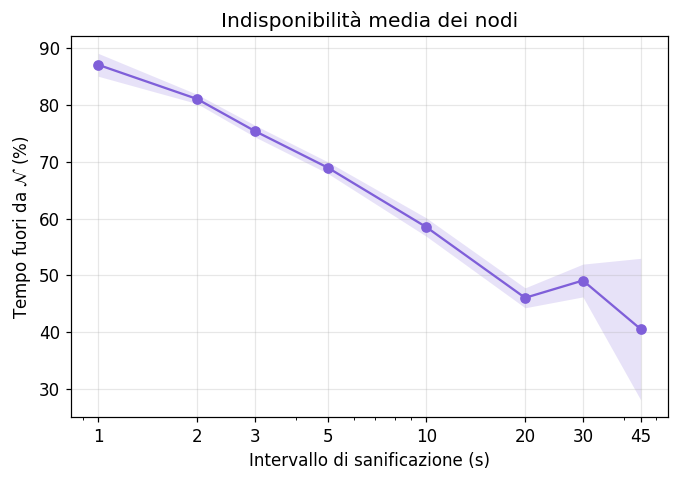

In [52]:
unavail = utils.node_unavailability(nodes, runs)
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, unavail, "#7f5fd9", scale=100)
set_log_x(ax)
ax.set_ylabel(r"Tempo fuori da $\mathcal{N}$ (%)")
ax.set_title("Indisponibilità media dei nodi")
fig.savefig(FIG_DIR / "sanitize_disponibilita.pdf")
plt.show()


## 5. Distribuzione cumulata della latenza (CDF)

**Cosa si valuta.** La CDF empirica della latenza, una curva per intervallo (repliche concatenate). Rende visibile l'intera distribuzione, non solo media/mediana.

**Cosa dice il grafico.** L'altezza del primo gradino (salita rapida vicino a zero) è la frazione di task non bloccati; la coda a destra è la popolazione dei bloccati. All'aumentare dell'intervallo la curva si "sdraia" verso destra: più task finiscono nella coda e la coda si allunga. Il ventaglio delle curve (dal chiaro al scuro) mostra a colpo d'occhio come cresce la componente bloccata con l'intervallo. È la giustificazione visiva della divergenza media/mediana della sezione 2.

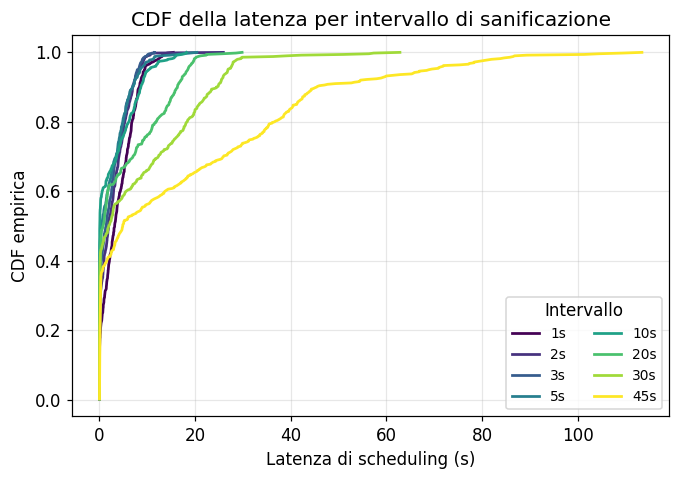

In [53]:
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 4.5))
for k, point in enumerate(INTERVALS):
    x, y = utils.ecdf(tasks[tasks["point"] == point]["latency_s"])
    ax.plot(x, y, ls="-", lw=1.8, color=cmap(k / max(1, len(INTERVALS) - 1)), label=f"{point}s")
ax.set_xlabel("Latenza di scheduling (s)")
ax.set_ylabel("CDF empirica")
ax.set_title("CDF della latenza per intervallo di sanificazione")
ax.legend(title="Intervallo", ncol=2, fontsize=9)
fig.savefig(FIG_DIR / "sanitize_cdf.pdf")
plt.show()


## 6. Makespan

**Cosa si valuta.** Tempo complessivo di completamento del batch (dal primo invio all'ultimo completamento), media tra repliche. Vista "di sistema": traduce il ritardo per-task in ritardo dell'intero carico.

**Cosa dice il grafico.** Cresce con l'intervallo negli scenari dove i blocchi allungano la coda finale di esecuzione. È in parte tautologico (più latenza → più makespan), ma è la metrica che risponde alla domanda pratica "quanto ci mette il batch a finire". Anche qui la banda si allarga a destra per l'effetto pochi-tick-per-run.

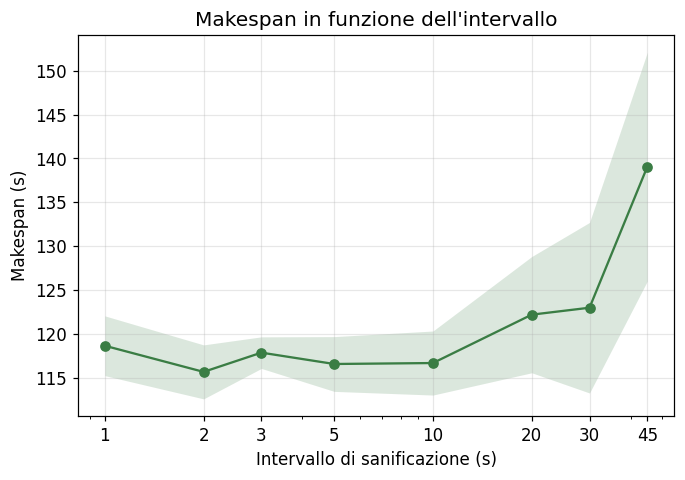

In [54]:
mk = runs.groupby("point")["makespan_s"].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, mk, "#3a7d44")
set_log_x(ax)
ax.set_ylabel("Makespan (s)")
ax.set_title("Makespan in funzione dell'intervallo")
fig.savefig(FIG_DIR / "sanitize_makespan.pdf")
plt.show()


## 7. Tabella riassuntiva

Una riga per intervallo con tutte le metriche principali (latenza media/mediana/p95, % bloccati, attesa media, indisponibilità, makespan). Esportata in LaTeX per l'inclusione diretta in tesi. È il riferimento numerico da citare nel testo a supporto delle figure.

In [55]:
summary = pd.DataFrame(index=lat.index)
summary["Latenza media (s)"] = lat["mean"].round(3)
summary["Dev. std (s)"] = lat["std"].round(3)
summary["Mediana (s)"] = med["mean"].round(3)
summary["Bloccati (%)"] = (tasks.groupby("point")["blocked"].mean() * 100).round(1)
summary["Attesa media (s)"] = wait["mean"].round(2)
summary["Fuori da N (%)"] = (unavail["mean"] * 100).round(1)
summary["Makespan (s)"] = mk["mean"].round(2)
summary.index.name = "Intervallo (s)"
display(summary)
summary.to_latex(TAB_DIR / "sanitize_riepilogo.tex", escape=False)
print("Figure in", FIG_DIR, "| tabelle in", TAB_DIR)

,Latenza media (s),Dev. std (s),Mediana (s),Bloccati (%),Attesa media (s),Fuori da N (%),Makespan (s)
Intervallo (s),,,,,,,
1,3.822,0.499,3.040,81.4,4.61,87.1,118.63
2,2.824,0.512,2.011,71.0,3.89,81.1,115.65
3,2.481,0.371,1.486,62.4,3.88,75.4,117.85
5,2.380,0.287,0.541,53.8,4.32,69.0,116.55
10,2.663,0.779,0.201,43.6,5.84,58.5,116.66
20,4.919,0.559,0.749,42.4,11.02,46.0,122.18
30,8.078,2.129,2.343,47.6,16.28,49.1,122.97
45,17.662,1.856,4.890,52.0,33.04,40.5,139.05


Figure in analysis\figures | tabelle in analysis\tables
